# Week 16 — Tuesday (Jul 9): Monocular Depth Estimation

## Learning Objectives
- Understand monocular depth estimation — predicting per-pixel depth from a **single** RGB image, no stereo baseline required
- Understand why MiDaS uses a scale-and-shift-invariant loss, and what that means for its output (relative, not metric, depth)
- Understand DPT's contribution — a Vision Transformer backbone instead of a CNN, for more globally consistent depth
- Understand monodepth2's self-supervised training signal (photometric reprojection between video frames)
- Run a pretrained monocular depth model on a video sequence and produce a colored depth video

## Key Concepts
1. **Monocular depth** — a single network `D(x) → depth map`, no second camera/baseline like Monday's stereo pipeline
2. **MiDaS** (Ranftl et al., 2020) — trained jointly on many datasets with different, unknown depth scales, using a **scale-and-shift-invariant loss** so it can learn from all of them at once. Output is *relative* inverse depth, not metres
3. **DPT** (Dense Prediction Transformer) — replaces MiDaS's CNN encoder with a ViT, giving the decoder access to global context at every layer instead of only through a shrinking receptive field
4. **monodepth2** — trained **self-supervised**: a depth network and a pose network are trained jointly so that warping frame `t-1` into frame `t` using the predicted depth + camera motion reproduces frame `t` (photometric reprojection loss) — no ground-truth depth needed at all
5. **Video vs single image** — running a per-frame model on video with no temporal term (as we do here) can flicker between frames; monodepth2's temporal training is one way this is addressed


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
from skimage import data as skdata
from skimage.transform import resize as sk_resize
import imageio.v2 as imageio

plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__} | Device: {DEVICE}')
print('Week 16 - Tuesday: Monocular Depth Estimation')

PyTorch 2.12.0+cpu | Device: cpu
Week 16 - Tuesday: Monocular Depth Estimation


## Section 1: Load Pretrained MiDaS

We use `MiDaS_small` (Intel ISL) via `torch.hub` — the lightweight EfficientNet-Lite backbone
variant, fast enough to run every frame of a video on CPU. It was trained across ~10 mixed
datasets (indoor, outdoor, synthetic) with a loss that's invariant to each dataset's unknown
depth scale/shift — which is exactly why its output is **relative** depth, not metres like
Monday's calibrated stereo depth.


In [2]:
# ── Load pretrained MiDaS_small + its preprocessing transform ─────────────────
midas = torch.hub.load('intel-isl/MiDaS', 'MiDaS_small', trust_repo=True).to(DEVICE).eval()
midas_transforms = torch.hub.load('intel-isl/MiDaS', 'transforms', trust_repo=True)
transform = midas_transforms.small_transform
print(f'MiDaS_small params: {sum(p.numel() for p in midas.parameters()):,}')

def predict_depth(img_rgb_uint8):
    """img_rgb_uint8: HxWx3 uint8 -> HxW float32 relative inverse-depth map (larger = closer)."""
    inp = transform(img_rgb_uint8).to(DEVICE)
    with torch.no_grad():
        pred = midas(inp)
        pred = F.interpolate(pred.unsqueeze(1), size=img_rgb_uint8.shape[:2],
                              mode='bicubic', align_corners=False).squeeze()
    return pred.cpu().numpy()

Using cache found in C:\Users\User/.cache\torch\hub\intel-isl_MiDaS_master


Loading weights:  None


Using cache found in C:\Users\User/.cache\torch\hub\rwightman_gen-efficientnet-pytorch_master


MiDaS_small params: 21,320,545


Using cache found in C:\Users\User/.cache\torch\hub\intel-isl_MiDaS_master


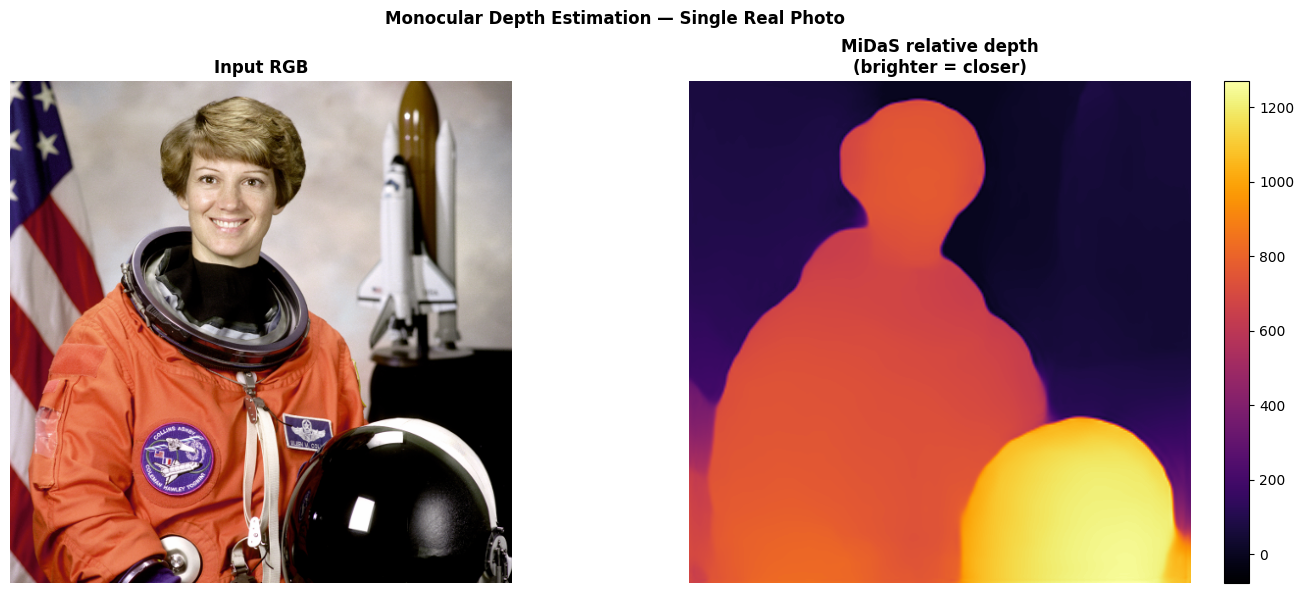

Saved monodepth_single.png


In [3]:
# ── Depth on a single real photo ───────────────────────────────────────────────
photo = skdata.astronaut()   # real 512x512x3 photo (scikit-image sample)
depth = predict_depth(photo)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(photo); axes[0].set_title('Input RGB', fontweight='bold'); axes[0].axis('off')
im = axes[1].imshow(depth, cmap='inferno')
axes[1].set_title('MiDaS relative depth\n(brighter = closer)', fontweight='bold'); axes[1].axis('off')
plt.colorbar(im, ax=axes[1], fraction=0.046)
plt.suptitle('Monocular Depth Estimation — Single Real Photo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('monodepth_single.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved monodepth_single.png')

## Section 2: Depth on a Video Sequence

This environment has no camera or video file to load, so we build a genuine (if synthetic-camera)
video the same way film cameras produce a "Ken Burns" shot: a slow pan/zoom over one real
photograph. This gives MiDaS a real sequence of RGB frames to process one at a time — exactly the
same code path as processing an actual recorded video, frame by frame.


Built 16 frames (256x256) — simulated pan/zoom video


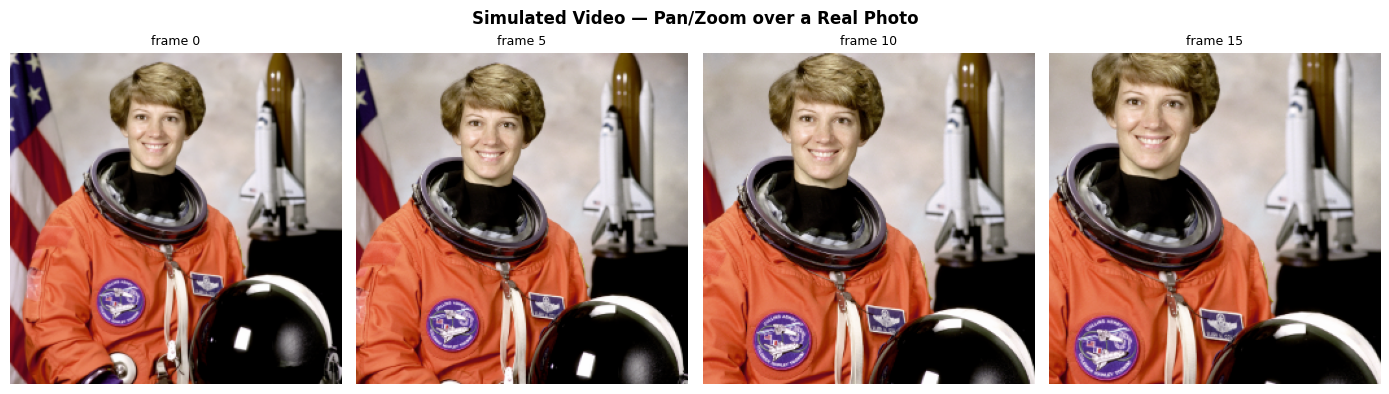

Saved video_frames.png


In [4]:
# ── Build a short video via simulated camera pan/zoom over a real photo ───────
N_FRAMES = 16
FRAME_SIZE = 256
H, W = photo.shape[:2]

frames = []
for i in range(N_FRAMES):
    t = i / (N_FRAMES - 1)
    zoom = 1.0 - 0.25 * t                       # zoom in over time
    cx, cy = 0.5 + 0.08*t, 0.42 + 0.04*t         # slow pan
    half_w, half_h = zoom * W / 2, zoom * H / 2
    x0 = int(np.clip(cx*W - half_w, 0, W - 2*half_w))
    y0 = int(np.clip(cy*H - half_h, 0, H - 2*half_h))
    crop = photo[y0:y0+int(2*half_h), x0:x0+int(2*half_w)]
    frame = (sk_resize(crop, (FRAME_SIZE, FRAME_SIZE), anti_aliasing=True) * 255).astype(np.uint8)
    frames.append(frame)

print(f'Built {len(frames)} frames ({FRAME_SIZE}x{FRAME_SIZE}) — simulated pan/zoom video')
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, idx in enumerate([0, 5, 10, 15]):
    axes[i].imshow(frames[idx]); axes[i].set_title(f'frame {idx}', fontsize=9); axes[i].axis('off')
plt.suptitle('Simulated Video — Pan/Zoom over a Real Photo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('video_frames.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved video_frames.png')

Global depth range across video: [0.000, 1740.850] (used to keep colour scale consistent frame-to-frame)


Saved depth_video.gif (16 frames, RGB | colored depth side-by-side)


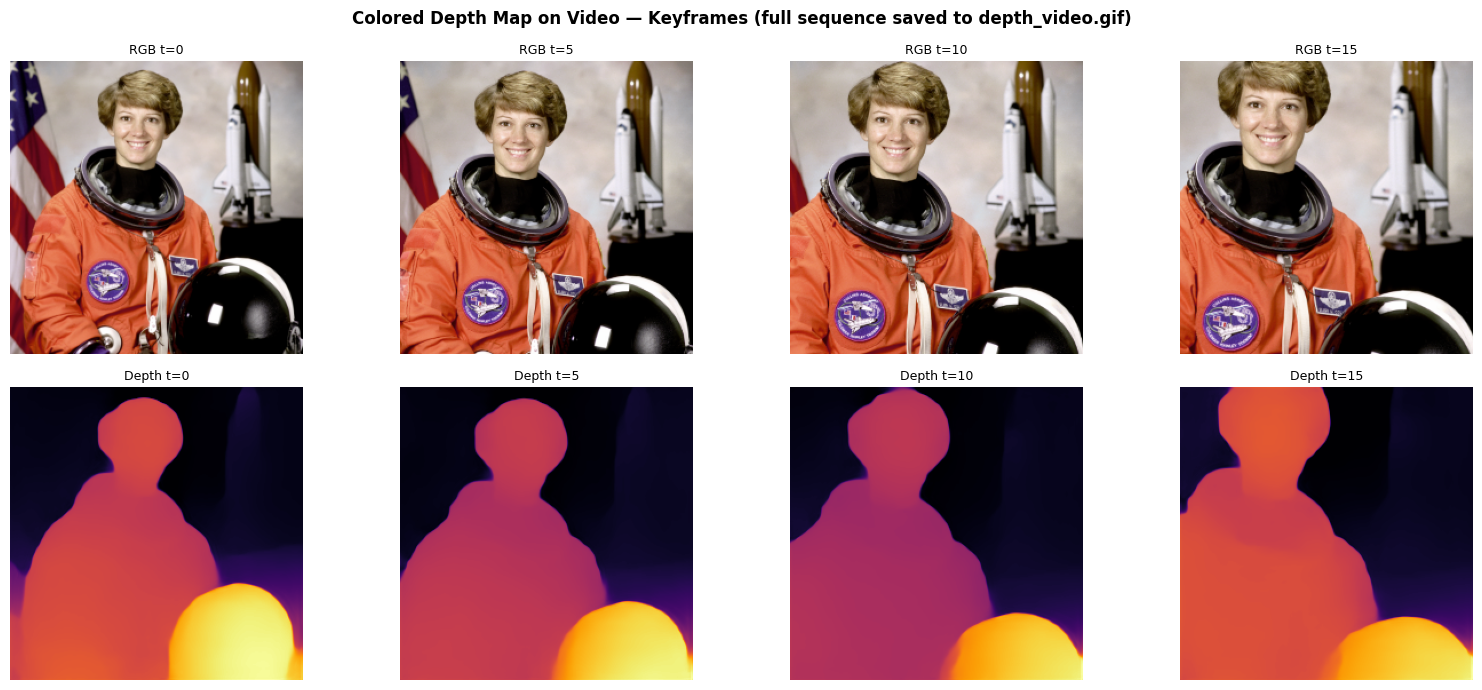

Saved monodepth_video_keyframes.png


In [5]:
# ── Run MiDaS on every frame, colorize with a shared (global) scale ───────────
depths = [predict_depth(f) for f in frames]
d_min = min(d.min() for d in depths)
d_max = max(d.max() for d in depths)
print(f'Global depth range across video: [{d_min:.3f}, {d_max:.3f}] (used to keep colour scale consistent frame-to-frame)')

cmap = cm.get_cmap('inferno')
colored_frames = []
for f, d in zip(frames, depths):
    d_norm = (d - d_min) / (d_max - d_min + 1e-8)
    depth_rgb = (cmap(d_norm)[..., :3] * 255).astype(np.uint8)
    side_by_side = np.concatenate([f, depth_rgb], axis=1)
    colored_frames.append(side_by_side)

imageio.mimsave('depth_video.gif', colored_frames, duration=0.15, loop=0)
print(f'Saved depth_video.gif ({len(colored_frames)} frames, RGB | colored depth side-by-side)')

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i, idx in enumerate([0, 5, 10, 15]):
    axes[0, i].imshow(frames[idx]); axes[0, i].axis('off'); axes[0, i].set_title(f'RGB t={idx}', fontsize=9)
    d_norm = (depths[idx] - d_min) / (d_max - d_min + 1e-8)
    axes[1, i].imshow(d_norm, cmap='inferno'); axes[1, i].axis('off'); axes[1, i].set_title(f'Depth t={idx}', fontsize=9)
plt.suptitle('Colored Depth Map on Video — Keyframes (full sequence saved to depth_video.gif)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('monodepth_video_keyframes.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved monodepth_video_keyframes.png')

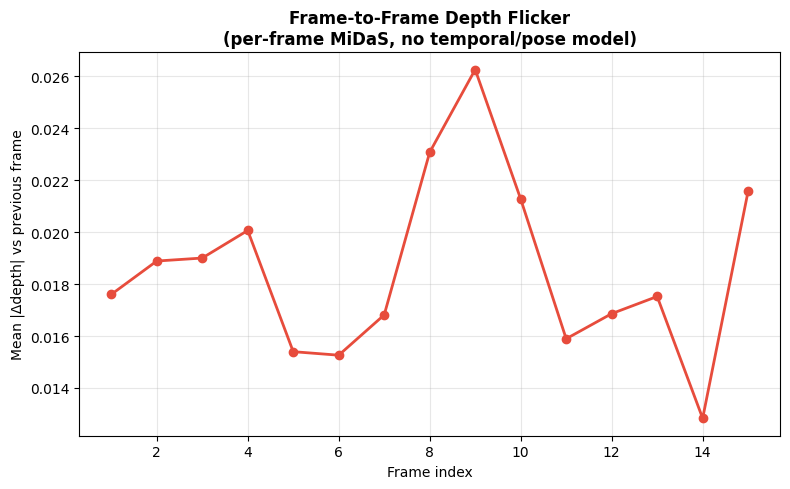

Mean frame-to-frame depth change: 0.0186
Saved depth_temporal_consistency.png


In [6]:
# ── Temporal consistency: frame-to-frame depth flicker (no temporal model used) ─
frame_diffs = []
for i in range(1, len(depths)):
    d0 = (depths[i-1] - d_min) / (d_max - d_min + 1e-8)
    d1 = (depths[i]   - d_min) / (d_max - d_min + 1e-8)
    frame_diffs.append(np.mean(np.abs(d1 - d0)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(depths)), frame_diffs, marker='o', color='#e74c3c', lw=2)
ax.set_xlabel('Frame index'); ax.set_ylabel('Mean |Δdepth| vs previous frame')
ax.set_title('Frame-to-Frame Depth Flicker\n(per-frame MiDaS, no temporal/pose model)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('depth_temporal_consistency.png', dpi=100, bbox_inches='tight')
plt.show()
print(f'Mean frame-to-frame depth change: {np.mean(frame_diffs):.4f}')
print('Saved depth_temporal_consistency.png')

## Section 3: Why monodepth2 Adds a Pose Network

The flicker above happens because every frame is depth-estimated **independently** — nothing ties
frame `t` to frame `t-1`. **monodepth2** (Godard et al., 2019) fixes exactly this, and does it
**self-supervised** (no ground-truth depth at all):

1. A **depth network** predicts `D_t` for frame `t`
2. A **pose network** predicts the camera motion `T_{t→t-1}` between adjacent frames
3. Using `D_t` and `T_{t→t-1}`, frame `t-1` is **warped** into frame `t`'s viewpoint (inverse warping via the pinhole camera model)
4. The training loss is the **photometric reprojection error** between the warped frame and the real frame `t` — if the warp used the right depth and the right motion, the warped frame should look like the real one

Because both depth and pose come from the same short video clip, this couples consecutive frames'
depth estimates together at *training* time, which is what produces smoother, less flickery depth
across a video compared to running a purely per-frame model like we did above.

> monodepth2 training itself isn't run here (it needs a proper video dataset with camera motion
> and several epochs of joint depth+pose training) — this section explains the mechanism that
> would resolve the flicker measured in Section 2.


## Key Takeaways

| Concept | Summary |
|---------|--------|
| **Monocular vs stereo depth** | One image, one network — no baseline/second camera, but output is *relative* depth, not metric |
| **MiDaS scale/shift-invariant loss** | Lets one model train across many datasets with unknown, inconsistent depth scales |
| **DPT** | Swaps MiDaS's CNN encoder for a ViT — every decoder layer sees global image context, not just a local receptive field |
| **monodepth2** | Self-supervised via photometric reprojection between video frames — depth + pose networks trained jointly, no depth labels needed |
| **Per-frame video depth** | Running a single-image model on every frame independently is simple but can flicker — measured here as frame-to-frame `mean|Δdepth|` |
| **Colored depth video** | Use a **global** (not per-frame) min/max when colorizing, or the color scale itself will flicker even if the depth doesn't |
